In [1]:
# ============================================================
# PHASE 4 — NLP / SEMANTIC REQUIREMENT MATCHING
# BidGuard AI
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np
from pathlib import Path

print("=== PHASE 4: NLP / SEMANTIC MATCHING ===")
print("NLP environment initialized successfully.")

=== PHASE 4: NLP / SEMANTIC MATCHING ===
NLP environment initialized successfully.


In [2]:
# ============================================================
# STEP 1 — IDENTIFY NLP DATA SOURCES
# ============================================================

from pathlib import Path

project_root = Path("..")
data_dir = project_root / "data"

print("=== DATA DIRECTORY CHECK ===")
print("Data directory exists:", data_dir.exists())
print()

print("=== DATA FILES FOUND ===")

data_files = []

for path in data_dir.rglob("*"):
    if path.is_file():
        data_files.append(path)

if not data_files:
    print("No files found inside data directory.")
else:
    for path in sorted(data_files):
        print(path.relative_to(project_root))

=== DATA DIRECTORY CHECK ===
Data directory exists: True

=== DATA FILES FOUND ===
data\metadata\dataset_metadata.json
data\metadata\dataset_summary.json
data\metadata\validation_report.json
data\processed\audit_trail.csv
data\processed\bidder_tenders.csv
data\processed\bidders.csv
data\processed\compliance_results.csv
data\processed\document_fields.csv
data\processed\document_pages.csv
data\processed\document_text.json
data\processed\documents.csv
data\processed\evidence.csv
data\processed\evidence_embeddings.npy
data\processed\recommendations.csv
data\processed\requirement_embeddings.npy
data\processed\requirement_evidence.csv
data\processed\risk_dataset.csv
data\processed\tender_requirements.csv
data\processed\tenders.csv
data\splits\test\bidder_tenders.csv
data\splits\test\documents.csv
data\splits\test\risk_dataset.csv
data\splits\test\tender_requirements.csv
data\splits\test\tenders.csv
data\splits\train\bidder_tenders.csv
data\splits\train\documents.csv
data\splits\train\risk_da

In [3]:
# ============================================================
# STEP 2 — INSPECT REQUIREMENT & EVIDENCE DATA
# ============================================================

requirements_path = data_dir / "processed" / "tender_requirements.csv"
evidence_path = data_dir / "processed" / "evidence.csv"
mapping_path = data_dir / "processed" / "requirement_evidence.csv"

requirements_df = pd.read_csv(requirements_path)
evidence_df = pd.read_csv(evidence_path)
mapping_df = pd.read_csv(mapping_path)

print("=== REQUIREMENT DATASET ===")
print("Shape:", requirements_df.shape)
print("Columns:")
for col in requirements_df.columns:
    print(" -", col)

print("\nFirst 3 requirement records:")
display(requirements_df.head(3))


print("\n" + "=" * 60)
print("=== EVIDENCE DATASET ===")
print("Shape:", evidence_df.shape)
print("Columns:")
for col in evidence_df.columns:
    print(" -", col)

print("\nFirst 3 evidence records:")
display(evidence_df.head(3))


print("\n" + "=" * 60)
print("=== REQUIREMENT-EVIDENCE MAPPING ===")
print("Shape:", mapping_df.shape)
print("Columns:")
for col in mapping_df.columns:
    print(" -", col)

print("\nFirst 5 mapping records:")
display(mapping_df.head(5))

=== REQUIREMENT DATASET ===
Shape: (31233, 16)
Columns:
 - requirement_id
 - tender_id
 - requirement_text
 - requirement_category
 - requirement_subcategory
 - metric
 - minimum_value
 - maximum_value
 - unit
 - mandatory
 - required_document_type
 - validity_required
 - verification_type
 - severity_if_failed
 - difficulty_level
 - linguistic_variant

First 3 requirement records:


,requirement_id,tender_id,requirement_text,requirement_category,requirement_subcategory,metric,minimum_value,maximum_value,unit,mandatory,required_document_type,validity_required,verification_type,severity_if_failed,difficulty_level,linguistic_variant
0,REQ-000001,TND-000001,The bidder shall hold an active GST registration.,GST,GST,GST,NaN,NaN,NaN,True,GST Certificate,True,DATE_CHECK,CRITICAL,MEDIUM,3
1,REQ-000002,TND-000001,A valid PAN document shall be submitted.,PAN,PAN,PAN,NaN,NaN,NaN,True,PAN Document,False,FIELD_MATCH,CRITICAL,MEDIUM,2
2,REQ-000003,TND-000001,Relevant experience of 7 years or more shall b...,Experience,Experience,Experience,7.0,NaN,years,True,Experience Certificate,False,DATE_CHECK,CRITICAL,MEDIUM,2



=== EVIDENCE DATASET ===
Shape: (41845, 9)
Columns:
 - evidence_id
 - document_id
 - tender_id
 - bidder_id
 - page_number
 - text_snippet
 - evidence_type
 - relevance_label
 - extraction_confidence

First 3 evidence records:


,evidence_id,document_id,tender_id,bidder_id,page_number,text_snippet,evidence_type,relevance_label,extraction_confidence
0,EVD-000001,DOC-000001,TND-000001,BID-001090,1,DOCUMENT TITLE: GST Certificate — GridlineNetw...,INTRODUCTION,IRRELEVANT,0.930
1,EVD-000002,DOC-000001,TND-000001,BID-001090,4,BUSINESS NARRATIVE\nThe supplier describes cap...,NARRATIVE,RELEVANT,0.943
2,EVD-000003,DOC-000002,TND-000001,BID-001090,3,CERTIFICATE / ELIGIBILITY DETAILS\nsupporting_...,EVIDENCE,RELEVANT,0.768



=== REQUIREMENT-EVIDENCE MAPPING ===
Shape: (123703, 13)
Columns:
 - requirement_evidence_id
 - tender_id
 - bidder_id
 - requirement_id
 - document_id
 - evidence_id
 - page_number
 - requirement_text
 - evidence_text
 - semantic_relevance
 - evidence_sufficiency
 - evidence_confidence
 - final_evidence_label

First 5 mapping records:


,requirement_evidence_id,tender_id,bidder_id,requirement_id,document_id,evidence_id,page_number,requirement_text,evidence_text,semantic_relevance,evidence_sufficiency,evidence_confidence,final_evidence_label
0,RE-000001,TND-000001,BID-001090,REQ-000001,DOC-000001,EVD-000001,1.0,The bidder shall hold an active GST registration.,DOCUMENT TITLE: GST Certificate — GridlineNetw...,0.12,0.00,0.930,DOES_NOT_SUPPORT
1,RE-000002,TND-000001,BID-001090,REQ-000002,DOC-000006,EVD-000013,2.0,A valid PAN document shall be submitted.,ENTITY AND REGISTRATION\nCompany: GridlineNetw...,0.92,0.92,0.835,SUPPORTS
2,RE-000003,TND-000001,BID-001090,REQ-000003,DOC-000007,EVD-000014,2.0,Relevant experience of 7 years or more shall b...,ENTITY AND REGISTRATION\nCompany: GridlineNetw...,0.92,0.92,0.724,SUPPORTS
3,RE-000004,TND-000001,BID-001090,REQ-000004,DOC-000005,EVD-000011,2.0,Bidder must have a minimum average annual turn...,ENTITY AND REGISTRATION\nCompany: GridlineNetw...,0.92,0.92,0.908,SUPPORTS
4,RE-000005,TND-000001,BID-001090,REQ-000005,DOC-000004,EVD-000009,3.0,The bidder shall submit authorization from the...,CERTIFICATE / ELIGIBILITY DETAILS\nauthorizati...,0.12,0.00,0.899,DOES_NOT_SUPPORT


In [4]:
# ============================================================
# STEP 3 — NLP DATA QUALITY & LABEL DISTRIBUTION
# ============================================================

print("=== NLP DATA QUALITY CHECK ===")

# Missing values
print("\n--- Missing Values ---")
print(mapping_df[["requirement_text", "evidence_text", "final_evidence_label"]].isna().sum())

# Empty text values
print("\n--- Empty Text Values ---")

empty_requirement = (
    mapping_df["requirement_text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

empty_evidence = (
    mapping_df["evidence_text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Empty requirement text:", empty_requirement)
print("Empty evidence text:", empty_evidence)

# Duplicate requirement-evidence pairs
print("\n--- Duplicate Requirement-Evidence Pairs ---")

duplicate_pairs = mapping_df.duplicated(
    subset=["requirement_text", "evidence_text"]
).sum()

print("Duplicate pairs:", duplicate_pairs)

# Text length statistics
mapping_df["requirement_text_length"] = (
    mapping_df["requirement_text"]
    .fillna("")
    .astype(str)
    .str.len()
)

mapping_df["evidence_text_length"] = (
    mapping_df["evidence_text"]
    .fillna("")
    .astype(str)
    .str.len()
)

print("\n--- Text Length Statistics ---")

print("\nRequirement text length:")
print(mapping_df["requirement_text_length"].describe())

print("\nEvidence text length:")
print(mapping_df["evidence_text_length"].describe())

# Label distribution
print("\n--- Final Evidence Label Distribution ---")

label_distribution = (
    mapping_df["final_evidence_label"]
    .value_counts(dropna=False)
)

print(label_distribution)

print("\nLabel percentages:")
print(
    (mapping_df["final_evidence_label"]
     .value_counts(normalize=True, dropna=False)
     .mul(100)
     .round(2))
)

print("\n=== NLP DATA QUALITY CHECK COMPLETED ===")

=== NLP DATA QUALITY CHECK ===

--- Missing Values ---
requirement_text            0
evidence_text           15141
final_evidence_label        0
dtype: int64

--- Empty Text Values ---
Empty requirement text: 0
Empty evidence text: 15141

--- Duplicate Requirement-Evidence Pairs ---
Duplicate pairs: 56824

--- Text Length Statistics ---

Requirement text length:
count    123703.000000
mean         78.327923
std          13.405025
min          36.000000
25%          69.000000
50%          79.000000
75%          88.000000
max         122.000000
Name: requirement_text_length, dtype: float64

Evidence text length:
count    123703.000000
mean        164.498994
std          75.010047
min           0.000000
25%         152.000000
50%         163.000000
75%         236.000000
max         361.000000
Name: evidence_text_length, dtype: float64

--- Final Evidence Label Distribution ---
final_evidence_label
SUPPORTS              74864
DOES_NOT_SUPPORT      17829
PARTIALLY_SUPPORTS    15869
NO_EVID

In [5]:
# ============================================================
# STEP 4 — CREATE LEAKAGE-SAFE NLP TRAIN / VALIDATION / TEST SETS
# ============================================================

print("=== LEAKAGE-SAFE NLP DATA SPLIT ===")

# Paths to existing tender-level splits
train_tenders_path = data_dir / "splits" / "train" / "tenders.csv"
validation_tenders_path = data_dir / "splits" / "validation" / "tenders.csv"
test_tenders_path = data_dir / "splits" / "test" / "tenders.csv"

# Load tender IDs from existing project splits
train_tenders_df = pd.read_csv(train_tenders_path)
validation_tenders_df = pd.read_csv(validation_tenders_path)
test_tenders_df = pd.read_csv(test_tenders_path)

train_tender_ids = set(train_tenders_df["tender_id"])
validation_tender_ids = set(validation_tenders_df["tender_id"])
test_tender_ids = set(test_tenders_df["tender_id"])

# Create NLP datasets using tender-level separation
nlp_train_df = mapping_df[
    mapping_df["tender_id"].isin(train_tender_ids)
].copy()

nlp_validation_df = mapping_df[
    mapping_df["tender_id"].isin(validation_tender_ids)
].copy()

nlp_test_df = mapping_df[
    mapping_df["tender_id"].isin(test_tender_ids)
].copy()

print("\n--- NLP Dataset Sizes ---")
print("Train      :", nlp_train_df.shape)
print("Validation :", nlp_validation_df.shape)
print("Test       :", nlp_test_df.shape)

print("\n--- Unique Tenders ---")
print("Train      :", nlp_train_df["tender_id"].nunique())
print("Validation :", nlp_validation_df["tender_id"].nunique())
print("Test       :", nlp_test_df["tender_id"].nunique())

print("\n--- Label Distribution: TRAIN ---")
print(nlp_train_df["final_evidence_label"].value_counts())

print("\n--- Label Distribution: VALIDATION ---")
print(nlp_validation_df["final_evidence_label"].value_counts())

print("\n--- Label Distribution: TEST ---")
print(nlp_test_df["final_evidence_label"].value_counts())

# Verify tender-level leakage
train_ids = set(nlp_train_df["tender_id"])
validation_ids = set(nlp_validation_df["tender_id"])
test_ids = set(nlp_test_df["tender_id"])

print("\n--- TENDER LEAKAGE CHECK ---")
print("Train ∩ Validation :", len(train_ids & validation_ids))
print("Train ∩ Test       :", len(train_ids & test_ids))
print("Validation ∩ Test  :", len(validation_ids & test_ids))

print("\n=== NLP SPLIT COMPLETED ===")

=== LEAKAGE-SAFE NLP DATA SPLIT ===

--- NLP Dataset Sizes ---
Train      : (86528, 15)
Validation : (18131, 15)
Test       : (19044, 15)

--- Unique Tenders ---
Train      : 840
Validation : 180
Test       : 180

--- Label Distribution: TRAIN ---
final_evidence_label
SUPPORTS              52408
DOES_NOT_SUPPORT      12428
PARTIALLY_SUPPORTS    11087
NO_EVIDENCE           10605
Name: count, dtype: int64

--- Label Distribution: VALIDATION ---
final_evidence_label
SUPPORTS              10934
DOES_NOT_SUPPORT       2621
PARTIALLY_SUPPORTS     2504
NO_EVIDENCE            2072
Name: count, dtype: int64

--- Label Distribution: TEST ---
final_evidence_label
SUPPORTS              11522
DOES_NOT_SUPPORT       2780
NO_EVIDENCE            2464
PARTIALLY_SUPPORTS     2278
Name: count, dtype: int64

--- TENDER LEAKAGE CHECK ---
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

=== NLP SPLIT COMPLETED ===


## 6. Text Preprocessing

Requirement and evidence text will be normalized before applying traditional NLP techniques.

Preprocessing steps:
- Convert text to lowercase
- Remove unnecessary whitespace
- Preserve meaningful words and numbers
- Handle missing evidence text
- Create clean requirement and evidence text columns

In [6]:
from pathlib import Path
import pandas as pd

print("=== LOADING NLP DATASET ===")

data_path = Path("../data/processed/requirement_evidence.csv")

nlp_df = pd.read_csv(data_path)

print("NLP dataset loaded successfully")
print("Shape:", nlp_df.shape)

print("\nColumns:")
for column in nlp_df.columns:
    print("-", column)

print("\nRequired NLP columns check:")

required_columns = [
    "requirement_text",
    "evidence_text",
    "final_evidence_label"
]

for column in required_columns:
    print(f"{column}: {column in nlp_df.columns}")

print("\n=== NLP DATASET LOADING COMPLETED ===")

=== LOADING NLP DATASET ===
NLP dataset loaded successfully
Shape: (123703, 13)

Columns:
- requirement_evidence_id
- tender_id
- bidder_id
- requirement_id
- document_id
- evidence_id
- page_number
- requirement_text
- evidence_text
- semantic_relevance
- evidence_sufficiency
- evidence_confidence
- final_evidence_label

Required NLP columns check:
requirement_text: True
evidence_text: True
final_evidence_label: True

=== NLP DATASET LOADING COMPLETED ===


In [7]:
from pathlib import Path

print("=== PATH DIAGNOSTIC ===")

print("Current working directory:")
print(Path.cwd())

print("\nProject root contents:")
for item in Path.cwd().iterdir():
    print("-", item)

print("\nSearching for requirement_evidence.csv...")

matches = list(Path.cwd().parent.rglob("requirement_evidence.csv"))

if matches:
    print("File found:")
    for path in matches:
        print(path)
else:
    print("requirement_evidence.csv NOT FOUND")

=== PATH DIAGNOSTIC ===
Current working directory:
c:\Users\Siddh\Desktop\BidGuard-AI\notebooks

Project root contents:
- c:\Users\Siddh\Desktop\BidGuard-AI\notebooks\01_dataset_eda.ipynb
- c:\Users\Siddh\Desktop\BidGuard-AI\notebooks\02_feature_engineering.ipynb
- c:\Users\Siddh\Desktop\BidGuard-AI\notebooks\03_ml_model_development.ipynb
- c:\Users\Siddh\Desktop\BidGuard-AI\notebooks\04_nlp_semantic_matching.ipynb
- c:\Users\Siddh\Desktop\BidGuard-AI\notebooks\models

Searching for requirement_evidence.csv...
File found:
c:\Users\Siddh\Desktop\BidGuard-AI\data\processed\requirement_evidence.csv


In [8]:
# ============================================
# NLP DATASET LOADING
# ============================================

import pandas as pd

nlp_df = pd.read_csv(
    "../data/processed/requirement_evidence.csv"
)

print("=== NLP DATASET LOADED SUCCESSFULLY ===")
print("Shape:", nlp_df.shape)

print("\nColumns:")
for col in nlp_df.columns:
    print("-", col)

print("\nRequired NLP columns check:")
print("requirement_text:", "requirement_text" in nlp_df.columns)
print("evidence_text:", "evidence_text" in nlp_df.columns)
print("final_evidence_label:", "final_evidence_label" in nlp_df.columns)

=== NLP DATASET LOADED SUCCESSFULLY ===
Shape: (123703, 13)

Columns:
- requirement_evidence_id
- tender_id
- bidder_id
- requirement_id
- document_id
- evidence_id
- page_number
- requirement_text
- evidence_text
- semantic_relevance
- evidence_sufficiency
- evidence_confidence
- final_evidence_label

Required NLP columns check:
requirement_text: True
evidence_text: True
final_evidence_label: True


In [9]:
# ============================================================
# BIDGUARD AI — COMPLETE PROJECT AUDIT
# ============================================================

from pathlib import Path
import pandas as pd
import subprocess

# Notebook is running from:
# BidGuard-AI/notebooks
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

print("=" * 70)
print("BIDGUARD AI — COMPLETE PROJECT AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. PROJECT ROOT
# ------------------------------------------------------------

print("\n[1] PROJECT ROOT")
print("Project root:", PROJECT_ROOT)
print("Exists:", PROJECT_ROOT.exists())

# ------------------------------------------------------------
# 2. PROJECT STRUCTURE
# ------------------------------------------------------------

print("\n[2] TOP-LEVEL PROJECT STRUCTURE")

for item in sorted(PROJECT_ROOT.iterdir()):
    if item.name != ".git":
        if item.is_dir():
            print(f"[DIR ] {item.name}/")
        else:
            print(f"[FILE] {item.name}")

# ------------------------------------------------------------
# 3. NOTEBOOKS
# ------------------------------------------------------------

print("\n[3] NOTEBOOKS")

notebooks_dir = PROJECT_ROOT / "notebooks"

if notebooks_dir.exists():
    for file in sorted(notebooks_dir.glob("*.ipynb")):
        print(f"- {file.name}")
else:
    print("NOT FOUND")

# ------------------------------------------------------------
# 4. DATA DIRECTORIES
# ------------------------------------------------------------

print("\n[4] DATA DIRECTORIES")

data_dir = PROJECT_ROOT / "data"

for folder in [
    data_dir,
    data_dir / "processed",
    data_dir / "metadata",
    data_dir / "splits",
    data_dir / "splits" / "train",
    data_dir / "splits" / "validation",
    data_dir / "splits" / "test",
]:
    print(f"{folder}: {folder.exists()}")

# ------------------------------------------------------------
# 5. PROCESSED DATA FILES
# ------------------------------------------------------------

print("\n[5] PROCESSED DATA FILES")

processed_dir = data_dir / "processed"

if processed_dir.exists():
    for file in sorted(processed_dir.iterdir()):
        print(f"- {file.name}")
else:
    print("Processed directory NOT FOUND")

# ------------------------------------------------------------
# 6. IMPORTANT DATASET SHAPES
# ------------------------------------------------------------

print("\n[6] IMPORTANT DATASET SHAPES")

important_files = [
    "tenders.csv",
    "bidder_tenders.csv",
    "bidders.csv",
    "tender_requirements.csv",
    "documents.csv",
    "document_pages.csv",
    "document_fields.csv",
    "document_text.json",
    "evidence.csv",
    "requirement_evidence.csv",
    "compliance_results.csv",
    "risk_dataset.csv",
    "recommendations.csv",
    "audit_trail.csv",
]

for filename in important_files:

    path = processed_dir / filename

    if not path.exists():
        print(f"- {filename}: NOT FOUND")
        continue

    try:
        if path.suffix.lower() == ".csv":
            df = pd.read_csv(path)
            print(f"- {filename}: {df.shape}")

        elif path.suffix.lower() == ".json":
            print(f"- {filename}: EXISTS")

    except Exception as e:
        print(f"- {filename}: ERROR -> {type(e).__name__}")

# ------------------------------------------------------------
# 7. TRAIN / VALIDATION / TEST SPLITS
# ------------------------------------------------------------

print("\n[7] TRAIN / VALIDATION / TEST SPLITS")

splits_dir = data_dir / "splits"

for split in ["train", "validation", "test"]:

    split_dir = splits_dir / split

    print(f"\n{split.upper()}:")

    if not split_dir.exists():
        print("  NOT FOUND")
        continue

    for file in sorted(split_dir.iterdir()):

        try:
            if file.suffix.lower() == ".csv":
                df = pd.read_csv(file)
                print(f"  - {file.name}: {df.shape}")
            else:
                print(f"  - {file.name}")

        except Exception as e:
            print(f"  - {file.name}: ERROR")

# ------------------------------------------------------------
# 8. METADATA
# ------------------------------------------------------------

print("\n[8] METADATA FILES")

metadata_dir = data_dir / "metadata"

if metadata_dir.exists():
    for file in sorted(metadata_dir.iterdir()):
        print(f"- {file.name}")
else:
    print("Metadata directory NOT FOUND")

# ------------------------------------------------------------
# 9. OTHER PROJECT DIRECTORIES
# ------------------------------------------------------------

print("\n[9] OTHER PROJECT DIRECTORIES")

for folder_name in [
    "src",
    "models",
    "reports",
    "backend",
    "frontend",
    "tests",
]:

    folder = PROJECT_ROOT / folder_name

    print(f"\n{folder_name}/")

    if not folder.exists():
        print("  NOT FOUND")
        continue

    items = list(folder.rglob("*"))

    if not items:
        print("  EMPTY")
    else:
        for item in items[:30]:
            relative = item.relative_to(folder)
            print(f"  - {relative}")

        if len(items) > 30:
            print(f"  ... and {len(items) - 30} more")

# ------------------------------------------------------------
# 10. ROOT PROJECT FILES
# ------------------------------------------------------------

print("\n[10] IMPORTANT ROOT FILES")

for filename in [
    "requirements.txt",
    "README.md",
    ".gitignore",
]:

    path = PROJECT_ROOT / filename

    print(f"- {filename}: {path.exists()}")

# ------------------------------------------------------------
# 11. GIT STATUS
# ------------------------------------------------------------

print("\n[11] GIT STATUS")

try:

    result = subprocess.run(
        ["git", "status", "--short", "--branch"],
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True
    )

    print(result.stdout)

except Exception as e:
    print("Git status unavailable:", e)

# ------------------------------------------------------------
# 12. CURRENT NOTEBOOK LOCATION
# ------------------------------------------------------------

print("\n[12] NOTEBOOK ENVIRONMENT")

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)

print("\n" + "=" * 70)
print("PROJECT AUDIT COMPLETED")
print("=" * 70)

BIDGUARD AI — COMPLETE PROJECT AUDIT

[1] PROJECT ROOT
Project root: c:\Users\Siddh\Desktop\BidGuard-AI
Exists: True

[2] TOP-LEVEL PROJECT STRUCTURE
[FILE] .gitignore
[DIR ] .venv/
[DIR ] backend/
[DIR ] data/
[DIR ] frontend/
[DIR ] models/
[DIR ] notebooks/
[DIR ] reports/
[FILE] requirements.txt
[DIR ] src/
[DIR ] tests/

[3] NOTEBOOKS
- 01_dataset_eda.ipynb
- 02_feature_engineering.ipynb
- 03_ml_model_development.ipynb
- 04_nlp_semantic_matching.ipynb

[4] DATA DIRECTORIES
c:\Users\Siddh\Desktop\BidGuard-AI\data: True
c:\Users\Siddh\Desktop\BidGuard-AI\data\processed: True
c:\Users\Siddh\Desktop\BidGuard-AI\data\metadata: True
c:\Users\Siddh\Desktop\BidGuard-AI\data\splits: True
c:\Users\Siddh\Desktop\BidGuard-AI\data\splits\train: True
c:\Users\Siddh\Desktop\BidGuard-AI\data\splits\validation: True
c:\Users\Siddh\Desktop\BidGuard-AI\data\splits\test: True

[5] PROCESSED DATA FILES
- audit_trail.csv
- bidder_tenders.csv
- bidders.csv
- compliance_results.csv
- document_fields.csv


In [10]:
from pathlib import Path
import pandas as pd
import re

# ============================================================
# PHASE 4 — NLP TEXT PREPROCESSING
# ============================================================

# Notebook is inside BidGuard-AI/notebooks/
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "requirement_evidence.csv"

print("=== NLP TEXT PREPROCESSING ===")
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

# ------------------------------------------------------------
# Load the verified NLP dataset
# ------------------------------------------------------------
nlp_df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully")
print("Shape:", nlp_df.shape)

# ------------------------------------------------------------
# Verify required columns
# ------------------------------------------------------------
required_columns = [
    "requirement_text",
    "evidence_text",
    "final_evidence_label"
]

print("\n=== REQUIRED COLUMN CHECK ===")

for column in required_columns:
    print(f"{column}: {column in nlp_df.columns}")

# ------------------------------------------------------------
# Text cleaning function
# ------------------------------------------------------------
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Normalize whitespace and line breaks
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing whitespace
    text = text.strip()

    return text


# ------------------------------------------------------------
# Create cleaned text columns
# ------------------------------------------------------------
nlp_df["requirement_text_clean"] = (
    nlp_df["requirement_text"].apply(clean_text)
)

nlp_df["evidence_text_clean"] = (
    nlp_df["evidence_text"].apply(clean_text)
)

# ------------------------------------------------------------
# Text preprocessing validation
# ------------------------------------------------------------
print("\n=== PREPROCESSING COMPLETED ===")

print("Shape:", nlp_df.shape)

print("\nNew columns:")
print("- requirement_text_clean")
print("- evidence_text_clean")

print("\n=== ORIGINAL VS CLEANED REQUIREMENT ===")

print(
    nlp_df[
        ["requirement_text", "requirement_text_clean"]
    ].head(5).to_string(index=False)
)

print("\n=== ORIGINAL VS CLEANED EVIDENCE ===")

print(
    nlp_df[
        ["evidence_text", "evidence_text_clean"]
    ].head(5).to_string(index=False)
)

# ------------------------------------------------------------
# Check empty cleaned text
# ------------------------------------------------------------
print("\n=== EMPTY CLEANED TEXT CHECK ===")

print(
    "Empty requirement_text_clean:",
    (nlp_df["requirement_text_clean"] == "").sum()
)

print(
    "Empty evidence_text_clean:",
    (nlp_df["evidence_text_clean"] == "").sum()
)

print("\n=== NLP WORKING DATAFRAME READY ===")

=== NLP TEXT PREPROCESSING ===
Project root: c:\Users\Siddh\Desktop\BidGuard-AI
Dataset path: c:\Users\Siddh\Desktop\BidGuard-AI\data\processed\requirement_evidence.csv
Dataset exists: True

Dataset loaded successfully
Shape: (123703, 13)

=== REQUIRED COLUMN CHECK ===
requirement_text: True
evidence_text: True
final_evidence_label: True

=== PREPROCESSING COMPLETED ===
Shape: (123703, 15)

New columns:
- requirement_text_clean
- evidence_text_clean

=== ORIGINAL VS CLEANED REQUIREMENT ===
                                                                                           requirement_text                                                                                      requirement_text_clean
                                                          The bidder shall hold an active GST registration.                                                           the bidder shall hold an active gst registration.
                                                                   A vali

In [11]:
# ============================================================
# PHASE 4 — TF-IDF SEMANTIC MATCHING BASELINE
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("=== TF-IDF SEMANTIC MATCHING ===")

# ------------------------------------------------------------
# Prepare text
# ------------------------------------------------------------
requirements = nlp_df["requirement_text_clean"]

evidence = nlp_df["evidence_text_clean"]

print("Total records:", len(nlp_df))
print("Requirement texts:", len(requirements))
print("Evidence texts:", len(evidence))

# ------------------------------------------------------------
# Fit TF-IDF on the combined NLP corpus
# ------------------------------------------------------------
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

combined_text = pd.concat(
    [requirements, evidence],
    ignore_index=True
)

tfidf_vectorizer.fit(combined_text)

print("\nTF-IDF vocabulary size:", len(tfidf_vectorizer.vocabulary_))

# ------------------------------------------------------------
# Transform requirement and evidence texts
# ------------------------------------------------------------
requirement_tfidf = tfidf_vectorizer.transform(requirements)

evidence_tfidf = tfidf_vectorizer.transform(evidence)

print("Requirement TF-IDF shape:", requirement_tfidf.shape)
print("Evidence TF-IDF shape:", evidence_tfidf.shape)

# ------------------------------------------------------------
# Calculate row-wise cosine similarity
# ------------------------------------------------------------
semantic_similarity = []

for i in range(len(nlp_df)):
    req_vector = requirement_tfidf[i]
    ev_vector = evidence_tfidf[i]

    if req_vector.nnz == 0 or ev_vector.nnz == 0:
        similarity = 0.0
    else:
        similarity = cosine_similarity(
            req_vector,
            ev_vector
        )[0, 0]

    semantic_similarity.append(similarity)

# ------------------------------------------------------------
# Store similarity score
# ------------------------------------------------------------
nlp_df["tfidf_cosine_similarity"] = semantic_similarity

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------
print("\n=== TF-IDF SEMANTIC MATCHING COMPLETED ===")

print(
    "Similarity min:",
    nlp_df["tfidf_cosine_similarity"].min()
)

print(
    "Similarity max:",
    nlp_df["tfidf_cosine_similarity"].max()
)

print(
    "Similarity mean:",
    nlp_df["tfidf_cosine_similarity"].mean()
)

print(
    "Similarity median:",
    nlp_df["tfidf_cosine_similarity"].median()
)

print("\n=== SAMPLE RESULTS ===")

print(
    nlp_df[
        [
            "requirement_text",
            "evidence_text",
            "final_evidence_label",
            "tfidf_cosine_similarity"
        ]
    ].head(10).to_string(index=False)
)

print("\n=== EMPTY EVIDENCE SIMILARITY CHECK ===")

empty_evidence_mask = (
    nlp_df["evidence_text_clean"] == ""
)

print(
    "Empty evidence records:",
    empty_evidence_mask.sum()
)

print(
    "Mean similarity for empty evidence:",
    nlp_df.loc[
        empty_evidence_mask,
        "tfidf_cosine_similarity"
    ].mean()
)

print("\n=== NLP BASELINE READY ===")

=== TF-IDF SEMANTIC MATCHING ===
Total records: 123703
Requirement texts: 123703
Evidence texts: 123703

TF-IDF vocabulary size: 10000
Requirement TF-IDF shape: (123703, 10000)
Evidence TF-IDF shape: (123703, 10000)

=== TF-IDF SEMANTIC MATCHING COMPLETED ===
Similarity min: 0.0
Similarity max: 0.2138112218115047
Similarity mean: 0.010990632045311567
Similarity median: 0.0

=== SAMPLE RESULTS ===
                                                                                           requirement_text                                                                                                                                                                                                                                                                                                                    evidence_text final_evidence_label  tfidf_cosine_similarity
                                                          The bidder shall hold an active GST registration.                  

In [12]:
# ============================================================
# PHASE 4 — TF-IDF BASELINE ANALYSIS BY EVIDENCE LABEL
# ============================================================

print("=== TF-IDF SIMILARITY BY EVIDENCE LABEL ===")

label_similarity_summary = (
    nlp_df
    .groupby("final_evidence_label")["tfidf_cosine_similarity"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .sort_values("mean", ascending=False)
)

print(label_similarity_summary)

print("\n=== ZERO-SIMILARITY RATE BY LABEL ===")

zero_similarity_rate = (
    nlp_df
    .assign(
        zero_similarity=
        nlp_df["tfidf_cosine_similarity"].eq(0)
    )
    .groupby("final_evidence_label")["zero_similarity"]
    .mean()
    .mul(100)
    .round(2)
)

print(zero_similarity_rate)

print("\n=== HIGH-SIMILARITY RECORDS ===")

high_similarity = (
    nlp_df[
        nlp_df["tfidf_cosine_similarity"] >= 0.10
    ][
        [
            "requirement_text",
            "evidence_text",
            "final_evidence_label",
            "tfidf_cosine_similarity"
        ]
    ]
    .sort_values(
        "tfidf_cosine_similarity",
        ascending=False
    )
    .head(10)
)

print(high_similarity.to_string(index=False))

print("\n=== TF-IDF BASELINE LABEL ANALYSIS COMPLETED ===")

=== TF-IDF SIMILARITY BY EVIDENCE LABEL ===
                      count      mean   median  min       max
final_evidence_label                                         
PARTIALLY_SUPPORTS    15869  0.013722  0.00000  0.0  0.212780
DOES_NOT_SUPPORT      17829  0.013553  0.00000  0.0  0.213811
SUPPORTS              74864  0.012024  0.00711  0.0  0.080943
NO_EVIDENCE           15141  0.000000  0.00000  0.0  0.000000

=== ZERO-SIMILARITY RATE BY LABEL ===
final_evidence_label
DOES_NOT_SUPPORT       51.61
NO_EVIDENCE           100.00
PARTIALLY_SUPPORTS     50.15
SUPPORTS               48.49
Name: zero_similarity, dtype: float64

=== HIGH-SIMILARITY RECORDS ===
                                               requirement_text                                                                                                                                evidence_text final_evidence_label  tfidf_cosine_similarity
                       A valid PAN document shall be submitted.              DOCUMENT 

In [13]:
# ============================================================
# PHASE 4 — TF-IDF CLASSIFICATION BASELINE
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("=== TF-IDF CLASSIFICATION BASELINE ===")

# ------------------------------------------------------------
# Create leakage-safe train / validation / test masks
# ------------------------------------------------------------

train_tenders = set(
    pd.read_csv(
        PROJECT_ROOT / "data" / "splits" / "train" / "tenders.csv"
    )["tender_id"]
)

validation_tenders = set(
    pd.read_csv(
        PROJECT_ROOT / "data" / "splits" / "validation" / "tenders.csv"
    )["tender_id"]
)

test_tenders = set(
    pd.read_csv(
        PROJECT_ROOT / "data" / "splits" / "test" / "tenders.csv"
    )["tender_id"]
)

train_mask = nlp_df["tender_id"].isin(train_tenders)
validation_mask = nlp_df["tender_id"].isin(validation_tenders)
test_mask = nlp_df["tender_id"].isin(test_tenders)

print("\nDataset split:")
print("Train:", train_mask.sum())
print("Validation:", validation_mask.sum())
print("Test:", test_mask.sum())

# ------------------------------------------------------------
# IMPORTANT:
# Fit TF-IDF ONLY on training text
# ------------------------------------------------------------

tfidf_baseline_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

train_text = pd.concat(
    [
        nlp_df.loc[train_mask, "requirement_text_clean"],
        nlp_df.loc[train_mask, "evidence_text_clean"]
    ],
    ignore_index=True
)

tfidf_baseline_vectorizer.fit(train_text)

print(
    "\nTraining vocabulary size:",
    len(tfidf_baseline_vectorizer.vocabulary_)
)

# ------------------------------------------------------------
# Create combined requirement + evidence representation
# ------------------------------------------------------------

def create_combined_text(df):
    return (
        df["requirement_text_clean"]
        + " [SEP] "
        + df["evidence_text_clean"]
    )

X_train_text = create_combined_text(
    nlp_df.loc[train_mask]
)

X_validation_text = create_combined_text(
    nlp_df.loc[validation_mask]
)

X_test_text = create_combined_text(
    nlp_df.loc[test_mask]
)

# ------------------------------------------------------------
# Transform
# ------------------------------------------------------------

X_train_tfidf = tfidf_baseline_vectorizer.transform(
    X_train_text
)

X_validation_tfidf = tfidf_baseline_vectorizer.transform(
    X_validation_text
)

X_test_tfidf = tfidf_baseline_vectorizer.transform(
    X_test_text
)

y_train_nlp = nlp_df.loc[
    train_mask,
    "final_evidence_label"
]

y_validation_nlp = nlp_df.loc[
    validation_mask,
    "final_evidence_label"
]

y_test_nlp = nlp_df.loc[
    test_mask,
    "final_evidence_label"
]

print("\nTF-IDF matrix shapes:")
print("Train:", X_train_tfidf.shape)
print("Validation:", X_validation_tfidf.shape)
print("Test:", X_test_tfidf.shape)

# ------------------------------------------------------------
# Train baseline classifier
# ------------------------------------------------------------

tfidf_baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=26100
)

tfidf_baseline_model.fit(
    X_train_tfidf,
    y_train_nlp
)

# ------------------------------------------------------------
# Validation prediction
# ------------------------------------------------------------

y_validation_pred = tfidf_baseline_model.predict(
    X_validation_tfidf
)

validation_accuracy = accuracy_score(
    y_validation_nlp,
    y_validation_pred
)

validation_precision = precision_score(
    y_validation_nlp,
    y_validation_pred,
    average="macro",
    zero_division=0
)

validation_recall = recall_score(
    y_validation_nlp,
    y_validation_pred,
    average="macro",
    zero_division=0
)

validation_f1 = f1_score(
    y_validation_nlp,
    y_validation_pred,
    average="macro",
    zero_division=0
)

print("\n=== VALIDATION RESULTS ===")
print(f"Accuracy : {validation_accuracy:.4f}")
print(f"Precision: {validation_precision:.4f}")
print(f"Recall   : {validation_recall:.4f}")
print(f"Macro F1 : {validation_f1:.4f}")

print("\n=== VALIDATION CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_validation_nlp,
        y_validation_pred,
        zero_division=0
    )
)

print("=== VALIDATION CONFUSION MATRIX ===")

labels = [
    "SUPPORTS",
    "PARTIALLY_SUPPORTS",
    "DOES_NOT_SUPPORT",
    "NO_EVIDENCE"
]

print(
    pd.DataFrame(
        confusion_matrix(
            y_validation_nlp,
            y_validation_pred,
            labels=labels
        ),
        index=labels,
        columns=labels
    )
)

print("\n=== TF-IDF CLASSIFICATION BASELINE COMPLETED ===")

=== TF-IDF CLASSIFICATION BASELINE ===

Dataset split:
Train: 86528
Validation: 18131
Test: 19044

Training vocabulary size: 10000

TF-IDF matrix shapes:
Train: (86528, 10000)
Validation: (18131, 10000)
Test: (19044, 10000)

=== VALIDATION RESULTS ===
Accuracy : 0.6486
Precision: 0.5885
Recall   : 0.5971
Macro F1 : 0.5909

=== VALIDATION CLASSIFICATION REPORT ===
                    precision    recall  f1-score   support

  DOES_NOT_SUPPORT       0.24      0.30      0.27      2621
       NO_EVIDENCE       1.00      1.00      1.00      2072
PARTIALLY_SUPPORTS       0.29      0.36      0.32      2504
          SUPPORTS       0.82      0.73      0.77     10934

          accuracy                           0.65     18131
         macro avg       0.59      0.60      0.59     18131
      weighted avg       0.68      0.65      0.66     18131

=== VALIDATION CONFUSION MATRIX ===
                    SUPPORTS  PARTIALLY_SUPPORTS  DOES_NOT_SUPPORT  \
SUPPORTS                8011                1

In [14]:
# ============================================================
# PHASE 4 — SENTENCE TRANSFORMER ENVIRONMENT CHECK
# ============================================================

print("=== SENTENCE TRANSFORMER ENVIRONMENT CHECK ===")

try:
    import sentence_transformers

    print("sentence-transformers: INSTALLED")
    print("Version:", sentence_transformers.__version__)

except ImportError:
    print("sentence-transformers: NOT INSTALLED")

print("\n=== ENVIRONMENT CHECK COMPLETED ===")

=== SENTENCE TRANSFORMER ENVIRONMENT CHECK ===


c:\Users\Siddh\Desktop\BidGuard-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sentence-transformers: INSTALLED
Version: 6.1.0

=== ENVIRONMENT CHECK COMPLETED ===


In [15]:
# ============================================================
# PHASE 4 — SENTENCE TRANSFORMER VERIFICATION
# ============================================================

print("=== SENTENCE TRANSFORMER VERIFICATION ===")

import sentence_transformers
import torch

print("sentence-transformers version:", sentence_transformers.__version__)
print("torch version:", torch.__version__)

print("CUDA available:", torch.cuda.is_available())

print("\n=== SENTENCE TRANSFORMER IMPORT SUCCESSFUL ===")

=== SENTENCE TRANSFORMER VERIFICATION ===
sentence-transformers version: 6.1.0
torch version: 2.14.0+cpu
CUDA available: False

=== SENTENCE TRANSFORMER IMPORT SUCCESSFUL ===


In [16]:
# ============================================================
# PHASE 4 — SENTENCE EMBEDDING MODEL TEST
# ============================================================

from sentence_transformers import SentenceTransformer
import numpy as np

print("=== SENTENCE EMBEDDING MODEL TEST ===")

# Lightweight general-purpose sentence embedding model
embedding_model_name = "all-MiniLM-L6-v2"

print("Loading model:", embedding_model_name)

embedding_model = SentenceTransformer(
    embedding_model_name,
    device="cpu"
)

print("Model loaded successfully")

# ------------------------------------------------------------
# Small sample only
# ------------------------------------------------------------

sample_requirements = nlp_df[
    "requirement_text_clean"
].head(5).fillna("").tolist()

sample_evidence = nlp_df[
    "evidence_text_clean"
].head(5).fillna("").tolist()

# Generate embeddings
requirement_embeddings = embedding_model.encode(
    sample_requirements,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False
)

evidence_embeddings = embedding_model.encode(
    sample_evidence,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False
)

print("\n=== EMBEDDING OUTPUT ===")
print("Requirement embedding shape:", requirement_embeddings.shape)
print("Evidence embedding shape:", evidence_embeddings.shape)

print(
    "Embedding dimension:",
    requirement_embeddings.shape[1]
)

print(
    "Requirement embedding dtype:",
    requirement_embeddings.dtype
)

print("\n=== SAMPLE EMBEDDING TEST COMPLETED ===")

=== SENTENCE EMBEDDING MODEL TEST ===
Loading model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6443.54it/s]


Model loaded successfully

=== EMBEDDING OUTPUT ===
Requirement embedding shape: (5, 384)
Evidence embedding shape: (5, 384)
Embedding dimension: 384
Requirement embedding dtype: float32

=== SAMPLE EMBEDDING TEST COMPLETED ===


In [17]:
# ============================================================
# PHASE 4 — SENTENCE EMBEDDING SEMANTIC SIMILARITY TEST
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

print("=== SENTENCE EMBEDDING SEMANTIC SIMILARITY ===")

# ------------------------------------------------------------
# Use first 20 records for controlled verification
# ------------------------------------------------------------

sample_df = nlp_df[
    [
        "requirement_text",
        "evidence_text",
        "final_evidence_label",
        "requirement_text_clean",
        "evidence_text_clean"
    ]
].head(20).copy()

# Replace missing evidence text with empty string
sample_requirements = (
    sample_df["requirement_text_clean"]
    .fillna("")
    .tolist()
)

sample_evidence = (
    sample_df["evidence_text_clean"]
    .fillna("")
    .tolist()
)

# ------------------------------------------------------------
# Generate embeddings
# ------------------------------------------------------------

sample_requirement_embeddings = embedding_model.encode(
    sample_requirements,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False
)

sample_evidence_embeddings = embedding_model.encode(
    sample_evidence,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False
)

# ------------------------------------------------------------
# Calculate pairwise cosine similarity
# ------------------------------------------------------------

semantic_similarity = np.sum(
    sample_requirement_embeddings *
    sample_evidence_embeddings,
    axis=1
)

sample_df["embedding_cosine_similarity"] = semantic_similarity

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n=== SAMPLE SEMANTIC MATCHING RESULTS ===")

display(
    sample_df[
        [
            "requirement_text",
            "evidence_text",
            "final_evidence_label",
            "embedding_cosine_similarity"
        ]
    ]
)

# ------------------------------------------------------------
# Similarity statistics
# ------------------------------------------------------------

print("\n=== SIMILARITY STATISTICS ===")

print(
    "Minimum similarity :",
    round(sample_df["embedding_cosine_similarity"].min(), 4)
)

print(
    "Maximum similarity :",
    round(sample_df["embedding_cosine_similarity"].max(), 4)
)

print(
    "Mean similarity    :",
    round(sample_df["embedding_cosine_similarity"].mean(), 4)
)

print(
    "Median similarity  :",
    round(sample_df["embedding_cosine_similarity"].median(), 4)
)

print("\n=== SAMPLE SEMANTIC SIMILARITY TEST COMPLETED ===")

=== SENTENCE EMBEDDING SEMANTIC SIMILARITY ===

=== SAMPLE SEMANTIC MATCHING RESULTS ===


,requirement_text,evidence_text,final_evidence_label,embedding_cosine_similarity
0,The bidder shall hold an active GST registration.,DOCUMENT TITLE: GST Certificate — GridlineNetw...,DOES_NOT_SUPPORT,0.474488
1,A valid PAN document shall be submitted.,ENTITY AND REGISTRATION\nCompany: GridlineNetw...,SUPPORTS,0.260590
2,Relevant experience of 7 years or more shall b...,ENTITY AND REGISTRATION\nCompany: GridlineNetw...,SUPPORTS,0.121729
3,Bidder must have a minimum average annual turn...,ENTITY AND REGISTRATION\nCompany: GridlineNetw...,SUPPORTS,0.096855
4,The bidder shall submit authorization from the...,CERTIFICATE / ELIGIBILITY DETAILS\nauthorizati...,DOES_NOT_SUPPORT,0.489394
5,The bidder shall provide a declaration of appl...,BUSINESS NARRATIVE\nThe supplier describes cap...,DOES_NOT_SUPPORT,0.202340
6,The bidder shall demonstrate latest-year turno...,CERTIFICATE / ELIGIBILITY DETAILS\nfinancial_y...,PARTIALLY_SUPPORTS,0.217162
7,Applicable social-security registration shall ...,BUSINESS NARRATIVE\nThe supplier describes cap...,DOES_NOT_SUPPORT,0.305740
8,The bidder shall submit the required legal and...,BUSINESS NARRATIVE\nThe supplier describes cap...,DOES_NOT_SUPPORT,0.106597
9,"NSIC registration, where relied upon, shall be...",CERTIFICATE / ELIGIBILITY DETAILS\nsupporting_...,SUPPORTS,0.264507



=== SIMILARITY STATISTICS ===
Minimum similarity : 0.0969
Maximum similarity : 0.6863
Mean similarity    : 0.2786
Median similarity  : 0.2625

=== SAMPLE SEMANTIC SIMILARITY TEST COMPLETED ===


In [18]:
# ============================================================
# RESTORE SENTENCE TRANSFORMER MODEL
# ============================================================

from sentence_transformers import SentenceTransformer

print("=== LOADING SENTENCE TRANSFORMER MODEL ===")

model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully")
print("Model:", model)
print("Embedding dimension:", model.get_sentence_embedding_dimension())

=== LOADING SENTENCE TRANSFORMER MODEL ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4904.67it/s]


Model loaded successfully
Model: SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)
Embedding dimension: 384


C:\Users\Siddh\AppData\Local\Temp\ipykernel_4356\4290119322.py:13: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Embedding dimension:", model.get_sentence_embedding_dimension())


In [19]:
# ============================================================
# FULL DATASET SENTENCE-TRANSFORMER EMBEDDINGS
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=== FULL DATASET SEMANTIC EMBEDDING GENERATION ===")

# Safety check
print("NLP dataframe shape:", nlp_df.shape)

# Required columns
required_columns = [
    "requirement_text_clean",
    "evidence_text_clean"
]

for col in required_columns:
    if col not in nlp_df.columns:
        raise KeyError(f"Missing required column: {col}")

# ------------------------------------------------------------
# Prepare text
# ------------------------------------------------------------

requirements = nlp_df["requirement_text_clean"].fillna("").astype(str).tolist()
evidences = nlp_df["evidence_text_clean"].fillna("").astype(str).tolist()

print("Total records:", len(nlp_df))
print("Requirement texts:", len(requirements))
print("Evidence texts:", len(evidences))

# ------------------------------------------------------------
# Encode requirements
# ------------------------------------------------------------

print("\nEncoding requirement texts...")

requirement_embeddings = model.encode(
    requirements,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Requirement embeddings:", requirement_embeddings.shape)
print("Requirement dtype:", requirement_embeddings.dtype)

# ------------------------------------------------------------
# Encode evidence texts
# Empty evidence gets zero vector
# ------------------------------------------------------------

print("\nEncoding evidence texts...")

evidence_embeddings = np.zeros(
    (len(evidences), requirement_embeddings.shape[1]),
    dtype=np.float32
)

non_empty_mask = np.array([len(text.strip()) > 0 for text in evidences])

print("Non-empty evidence:", non_empty_mask.sum())
print("Empty evidence:", (~non_empty_mask).sum())

if non_empty_mask.any():

    evidence_embeddings[non_empty_mask] = model.encode(
        [evidences[i] for i in np.where(non_empty_mask)[0]],
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

print("Evidence embeddings:", evidence_embeddings.shape)
print("Evidence dtype:", evidence_embeddings.dtype)

# ------------------------------------------------------------
# One-to-one cosine similarity
# Because embeddings are normalized, dot product = cosine similarity
# ------------------------------------------------------------

semantic_similarity = np.sum(
    requirement_embeddings * evidence_embeddings,
    axis=1
)

# Explicitly force empty evidence similarity to 0
semantic_similarity[~non_empty_mask] = 0.0

nlp_df["embedding_cosine_similarity"] = semantic_similarity

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print("\n=== FULL SEMANTIC EMBEDDING GENERATION COMPLETED ===")

print("Requirement embedding shape:", requirement_embeddings.shape)
print("Evidence embedding shape:", evidence_embeddings.shape)

print("\nSimilarity statistics:")
print("Minimum:", float(semantic_similarity.min()))
print("Maximum:", float(semantic_similarity.max()))
print("Mean:", float(semantic_similarity.mean()))
print("Median:", float(np.median(semantic_similarity)))

print("\nEmpty evidence similarity check:")
print(
    "Maximum similarity among empty evidence:",
    float(
        semantic_similarity[~non_empty_mask].max()
    ) if (~non_empty_mask).any() else 0.0
)

=== FULL DATASET SEMANTIC EMBEDDING GENERATION ===
NLP dataframe shape: (123703, 16)
Total records: 123703
Requirement texts: 123703
Evidence texts: 123703

Encoding requirement texts...


Batches: 100%|██████████| 967/967 [04:19<00:00,  3.72it/s]


Requirement embeddings: (123703, 384)
Requirement dtype: float32

Encoding evidence texts...
Non-empty evidence: 108562
Empty evidence: 15141


Batches: 100%|██████████| 849/849 [11:19<00:00,  1.25it/s]


Evidence embeddings: (123703, 384)
Evidence dtype: float32

=== FULL SEMANTIC EMBEDDING GENERATION COMPLETED ===
Requirement embedding shape: (123703, 384)
Evidence embedding shape: (123703, 384)

Similarity statistics:
Minimum: -0.030007153749465942
Maximum: 0.787858784198761
Mean: 0.2627656161785126
Median: 0.2814752161502838

Empty evidence similarity check:
Maximum similarity among empty evidence: 0.0


In [20]:
# ============================================================
# SAVE FULL SEMANTIC EMBEDDINGS
# ============================================================

import os
import numpy as np

processed_dir = os.path.join(PROJECT_ROOT, "data", "processed")

requirement_embedding_path = os.path.join(
    processed_dir,
    "requirement_embeddings.npy"
)

evidence_embedding_path = os.path.join(
    processed_dir,
    "evidence_embeddings.npy"
)

np.save(requirement_embedding_path, requirement_embeddings)
np.save(evidence_embedding_path, evidence_embeddings)

print("=== EMBEDDINGS SAVED ===")
print("Requirement embeddings:", requirement_embedding_path)
print("Evidence embeddings:", evidence_embedding_path)

print("Requirement shape:", np.load(requirement_embedding_path, mmap_mode="r").shape)
print("Evidence shape:", np.load(evidence_embedding_path, mmap_mode="r").shape)

=== EMBEDDINGS SAVED ===
Requirement embeddings: c:\Users\Siddh\Desktop\BidGuard-AI\data\processed\requirement_embeddings.npy
Evidence embeddings: c:\Users\Siddh\Desktop\BidGuard-AI\data\processed\evidence_embeddings.npy
Requirement shape: (123703, 384)
Evidence shape: (123703, 384)


In [21]:
# ============================================================
# STORE SEMANTIC SIMILARITY
# ============================================================

nlp_df["embedding_cosine_similarity"] = semantic_similarity

print("=== SEMANTIC SIMILARITY STORED ===")

print(
    nlp_df[
        [
            "requirement_text",
            "evidence_text",
            "final_evidence_label",
            "embedding_cosine_similarity"
        ]
    ].head(10)
)

=== SEMANTIC SIMILARITY STORED ===
                                    requirement_text  \
0  The bidder shall hold an active GST registration.   
1           A valid PAN document shall be submitted.   
2  Relevant experience of 7 years or more shall b...   
3  Bidder must have a minimum average annual turn...   
4  The bidder shall submit authorization from the...   
5  The bidder shall provide a declaration of appl...   
6  The bidder shall demonstrate latest-year turno...   
7  Applicable social-security registration shall ...   
8  The bidder shall submit the required legal and...   
9  NSIC registration, where relied upon, shall be...   

                                       evidence_text final_evidence_label  \
0  DOCUMENT TITLE: GST Certificate — GridlineNetw...     DOES_NOT_SUPPORT   
1  ENTITY AND REGISTRATION\nCompany: GridlineNetw...             SUPPORTS   
2  ENTITY AND REGISTRATION\nCompany: GridlineNetw...             SUPPORTS   
3  ENTITY AND REGISTRATION\nCompany: Gri

In [22]:
# ============================================================
# SEMANTIC SIMILARITY BY LABEL
# ============================================================

semantic_by_label = (
    nlp_df
    .groupby("final_evidence_label")["embedding_cosine_similarity"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .sort_values("mean", ascending=False)
)

print("=== SEMANTIC SIMILARITY BY EVIDENCE LABEL ===")
display(semantic_by_label)

=== SEMANTIC SIMILARITY BY EVIDENCE LABEL ===


,count,mean,median,min,max
final_evidence_label,,,,,
SUPPORTS,74864,0.299519,0.302109,-0.030007,0.663894
DOES_NOT_SUPPORT,17829,0.299250,0.294519,-0.030007,0.787859
PARTIALLY_SUPPORTS,15869,0.299097,0.295052,-0.026013,0.785510
NO_EVIDENCE,15141,0.000000,0.000000,0.000000,0.000000


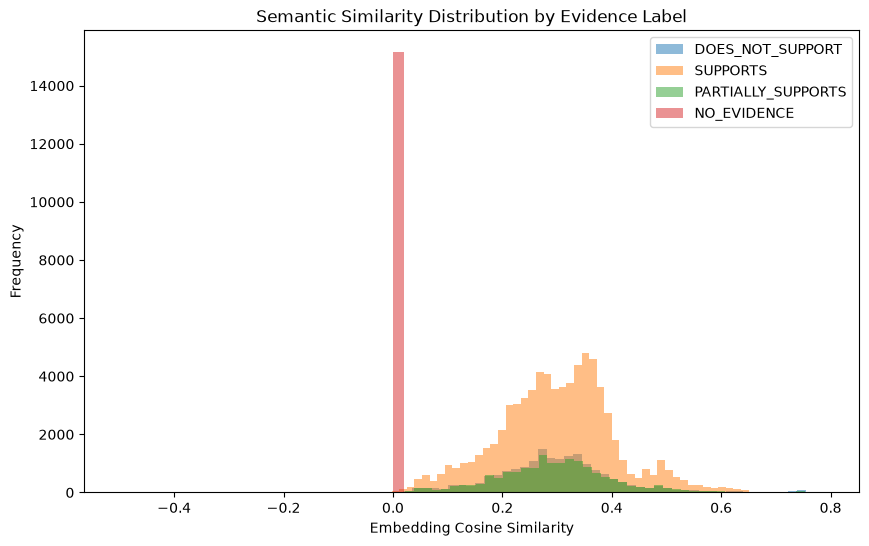

In [23]:
# ============================================================
# SEMANTIC SIMILARITY DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for label in nlp_df["final_evidence_label"].unique():
    values = nlp_df.loc[
        nlp_df["final_evidence_label"] == label,
        "embedding_cosine_similarity"
    ]

    plt.hist(
        values,
        bins=50,
        alpha=0.5,
        label=label
    )

plt.xlabel("Embedding Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Semantic Similarity Distribution by Evidence Label")
plt.legend()
plt.show()

In [24]:
import numpy as np

requirement_embeddings = np.load(
    "../data/processed/requirement_embeddings.npy"
)

evidence_embeddings = np.load(
    "../data/processed/evidence_embeddings.npy"
)

print("=== SAVED EMBEDDINGS LOADED ===")
print("Requirement embeddings:", requirement_embeddings.shape)
print("Evidence embeddings:", evidence_embeddings.shape)

=== SAVED EMBEDDINGS LOADED ===
Requirement embeddings: (123703, 384)
Evidence embeddings: (123703, 384)


In [25]:
# ============================================================
# SEMANTIC FEATURE CONSTRUCTION
# ============================================================

# Difference between requirement and evidence embeddings
embedding_difference = np.abs(
    requirement_embeddings - evidence_embeddings
)

# Existing cosine similarity as an additional feature
similarity_feature = nlp_df[
    "embedding_cosine_similarity"
].to_numpy().reshape(-1, 1)

# Combine both
X_semantic = np.hstack([
    embedding_difference,
    similarity_feature
])

# Target labels
y_semantic = nlp_df[
    "final_evidence_label"
].to_numpy()

print("=== SEMANTIC FEATURES CREATED ===")
print("Feature matrix shape:", X_semantic.shape)
print("Target shape:", y_semantic.shape)
print("Number of features:", X_semantic.shape[1])
print("Classes:", np.unique(y_semantic))

=== SEMANTIC FEATURES CREATED ===
Feature matrix shape: (123703, 385)
Target shape: (123703,)
Number of features: 385
Classes: ['DOES_NOT_SUPPORT' 'NO_EVIDENCE' 'PARTIALLY_SUPPORTS' 'SUPPORTS']


In [26]:
# ============================================================
# CHECK EXISTING TRAIN / VALIDATION / TEST SPLIT
# ============================================================

print("train_idx exists:", "train_idx" in globals())
print("val_idx exists:", "val_idx" in globals())
print("test_idx exists:", "test_idx" in globals())

print("\nPossible existing split variables:")

for name in ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]:
    print(name, "exists:", name in globals())

train_idx exists: False
val_idx exists: False
test_idx exists: False

Possible existing split variables:
X_train exists: False
X_val exists: False
X_test exists: False
y_train exists: False
y_val exists: False
y_test exists: False


In [27]:
# ============================================================
# GROUP-AWARE TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

groups = nlp_df["tender_id"].to_numpy()

# First: 70% Train, 30% Temporary
gss_train = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=26100
)

train_idx, temp_idx = next(
    gss_train.split(
        X_semantic,
        y_semantic,
        groups=groups
    )
)

# Second: split remaining 30% equally into
# 15% Validation and 15% Test
gss_val_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=26100
)

val_relative_idx, test_relative_idx = next(
    gss_val_test.split(
        X_semantic[temp_idx],
        y_semantic[temp_idx],
        groups=groups[temp_idx]
    )
)

val_idx = temp_idx[val_relative_idx]
test_idx = temp_idx[test_relative_idx]

print("=== GROUP-AWARE DATASET SPLIT ===")
print("Train records      :", len(train_idx))
print("Validation records :", len(val_idx))
print("Test records       :", len(test_idx))

print("\nUnique tenders:")
print("Train tenders      :", nlp_df.iloc[train_idx]["tender_id"].nunique())
print("Validation tenders :", nlp_df.iloc[val_idx]["tender_id"].nunique())
print("Test tenders       :", nlp_df.iloc[test_idx]["tender_id"].nunique())

print("\nTotal records:", len(train_idx) + len(val_idx) + len(test_idx))

=== GROUP-AWARE DATASET SPLIT ===
Train records      : 86607
Validation records : 19090
Test records       : 18006

Unique tenders:
Train tenders      : 840
Validation tenders : 180
Test tenders       : 180

Total records: 123703


In [28]:
from pathlib import Path
import numpy as np

PROJECT_ROOT = Path.cwd().parent

REQ_EMB_PATH = PROJECT_ROOT / "data" / "processed" / "requirement_embeddings.npy"
EVID_EMB_PATH = PROJECT_ROOT / "data" / "processed" / "evidence_embeddings.npy"

print("Requirement embeddings exists:", REQ_EMB_PATH.exists())
print("Evidence embeddings exists:", EVID_EMB_PATH.exists())

requirement_embeddings = np.load(REQ_EMB_PATH)
evidence_embeddings = np.load(EVID_EMB_PATH)

print("\n=== EMBEDDINGS LOADED ===")
print("Requirement:", requirement_embeddings.shape)
print("Evidence:", evidence_embeddings.shape)

Requirement embeddings exists: True
Evidence embeddings exists: True

=== EMBEDDINGS LOADED ===
Requirement: (123703, 384)
Evidence: (123703, 384)


In [29]:
# ============================================================
# PHASE 4 — REBUILD 385 SEMANTIC FEATURES
# ============================================================

import numpy as np

# 384-dimensional requirement + evidence embeddings
# plus the already-created semantic similarity feature
semantic_similarity = nlp_df["embedding_cosine_similarity"].to_numpy().reshape(-1, 1)

semantic_features = np.hstack([
    requirement_embeddings,
    evidence_embeddings,
    semantic_similarity
])

y = nlp_df["final_evidence_label"].to_numpy()

print("=== SEMANTIC FEATURES REBUILT ===")
print("Requirement embeddings:", requirement_embeddings.shape)
print("Evidence embeddings:", evidence_embeddings.shape)
print("Similarity feature:", semantic_similarity.shape)
print("Feature matrix:", semantic_features.shape)
print("Target:", y.shape)
print("Classes:", np.unique(y))

=== SEMANTIC FEATURES REBUILT ===
Requirement embeddings: (123703, 384)
Evidence embeddings: (123703, 384)
Similarity feature: (123703, 1)
Feature matrix: (123703, 769)
Target: (123703,)
Classes: ['DOES_NOT_SUPPORT' 'NO_EVIDENCE' 'PARTIALLY_SUPPORTS' 'SUPPORTS']


In [30]:
# ============================================================
# PHASE 4 — SEMANTIC TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Tender IDs from the already-created group-aware split
train_tenders = nlp_df.iloc[train_idx]["tender_id"].unique()
val_tenders   = nlp_df.iloc[val_idx]["tender_id"].unique()
test_tenders  = nlp_df.iloc[test_idx]["tender_id"].unique()

# Create masks
train_mask = nlp_df["tender_id"].isin(train_tenders)
val_mask   = nlp_df["tender_id"].isin(val_tenders)
test_mask  = nlp_df["tender_id"].isin(test_tenders)

# Split semantic features
X_train = semantic_features[train_mask]
X_val   = semantic_features[val_mask]
X_test  = semantic_features[test_mask]

# Split targets
y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

print("=== SEMANTIC TRAIN / VALIDATION / TEST SPLIT ===")

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

print("\nUnique train tenders:", len(train_tenders))
print("Unique validation tenders:", len(val_tenders))
print("Unique test tenders:", len(test_tenders))

print("\nTotal records:", len(X_train) + len(X_val) + len(X_test))

=== SEMANTIC TRAIN / VALIDATION / TEST SPLIT ===
X_train: (86607, 769)
X_val  : (19090, 769)
X_test : (18006, 769)

y_train: (86607,)
y_val  : (19090,)
y_test : (18006,)

Unique train tenders: 840
Unique validation tenders: 180
Unique test tenders: 180

Total records: 123703


In [31]:
# ============================================================
# CHECK SAVED PROJECT DATA
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

print("Project root:")
print(PROJECT_ROOT)

print("\nFiles inside data/:")
for path in DATA_DIR.rglob("*"):
    if path.is_file():
        print(path.relative_to(PROJECT_ROOT))

Project root:
c:\Users\Siddh\Desktop\BidGuard-AI

Files inside data/:
data\metadata\dataset_metadata.json
data\metadata\dataset_summary.json
data\metadata\validation_report.json
data\processed\audit_trail.csv
data\processed\bidders.csv
data\processed\bidder_tenders.csv
data\processed\compliance_results.csv
data\processed\documents.csv
data\processed\document_fields.csv
data\processed\document_pages.csv
data\processed\document_text.json
data\processed\evidence.csv
data\processed\evidence_embeddings.npy
data\processed\recommendations.csv
data\processed\requirement_embeddings.npy
data\processed\requirement_evidence.csv
data\processed\risk_dataset.csv
data\processed\tenders.csv
data\processed\tender_requirements.csv
data\splits\test\bidder_tenders.csv
data\splits\test\documents.csv
data\splits\test\risk_dataset.csv
data\splits\test\tenders.csv
data\splits\test\tender_requirements.csv
data\splits\train\bidder_tenders.csv
data\splits\train\documents.csv
data\splits\train\risk_dataset.csv
dat

In [32]:
# ============================================================
# RESTORE NLP DATAFRAME — STEP 1
# ============================================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

# Load the main NLP-related files
requirement_evidence = pd.read_csv(
    DATA_DIR / "processed" / "requirement_evidence.csv"
)

evidence = pd.read_csv(
    DATA_DIR / "processed" / "evidence.csv"
)

tender_requirements = pd.read_csv(
    DATA_DIR / "processed" / "tender_requirements.csv"
)

print("=== FILES LOADED ===")

print("\nrequirement_evidence:")
print(requirement_evidence.shape)
print(requirement_evidence.columns.tolist())

print("\nevidence:")
print(evidence.shape)
print(evidence.columns.tolist())

print("\ntender_requirements:")
print(tender_requirements.shape)
print(tender_requirements.columns.tolist())

=== FILES LOADED ===

requirement_evidence:
(123703, 13)
['requirement_evidence_id', 'tender_id', 'bidder_id', 'requirement_id', 'document_id', 'evidence_id', 'page_number', 'requirement_text', 'evidence_text', 'semantic_relevance', 'evidence_sufficiency', 'evidence_confidence', 'final_evidence_label']

evidence:
(41845, 9)
['evidence_id', 'document_id', 'tender_id', 'bidder_id', 'page_number', 'text_snippet', 'evidence_type', 'relevance_label', 'extraction_confidence']

tender_requirements:
(31233, 16)
['requirement_id', 'tender_id', 'requirement_text', 'requirement_category', 'requirement_subcategory', 'metric', 'minimum_value', 'maximum_value', 'unit', 'mandatory', 'required_document_type', 'validity_required', 'verification_type', 'severity_if_failed', 'difficulty_level', 'linguistic_variant']


In [33]:
# ============================================================
# RESTORE NLP DATAFRAME — STEP 2
# ============================================================

nlp_df = requirement_evidence.copy()

print("=== NLP DATAFRAME RESTORED ===")
print("Shape:", nlp_df.shape)

print("\nRequired columns:")
print([
    "tender_id",
    "requirement_text",
    "evidence_text",
    "final_evidence_label"
])

print("\nAvailable columns:")
print(nlp_df.columns.tolist())

print("\nLabel distribution:")
print(nlp_df["final_evidence_label"].value_counts())

print("\nUnique tenders:")
print(nlp_df["tender_id"].nunique())

=== NLP DATAFRAME RESTORED ===
Shape: (123703, 13)

Required columns:
['tender_id', 'requirement_text', 'evidence_text', 'final_evidence_label']

Available columns:
['requirement_evidence_id', 'tender_id', 'bidder_id', 'requirement_id', 'document_id', 'evidence_id', 'page_number', 'requirement_text', 'evidence_text', 'semantic_relevance', 'evidence_sufficiency', 'evidence_confidence', 'final_evidence_label']

Label distribution:
final_evidence_label
SUPPORTS              74864
DOES_NOT_SUPPORT      17829
PARTIALLY_SUPPORTS    15869
NO_EVIDENCE           15141
Name: count, dtype: int64

Unique tenders:
1200


In [34]:
# ============================================================
# RESTORE GROUP-AWARE TENDER SPLIT
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"

# Load tender IDs from saved split files
train_tenders_df = pd.read_csv(
    SPLIT_DIR / "train" / "tenders.csv"
)

val_tenders_df = pd.read_csv(
    SPLIT_DIR / "validation" / "tenders.csv"
)

test_tenders_df = pd.read_csv(
    SPLIT_DIR / "test" / "tenders.csv"
)

train_tenders = train_tenders_df["tender_id"].unique()
val_tenders = val_tenders_df["tender_id"].unique()
test_tenders = test_tenders_df["tender_id"].unique()

print("=== SAVED TENDER SPLIT RESTORED ===")

print("Train tenders      :", len(train_tenders))
print("Validation tenders :", len(val_tenders))
print("Test tenders       :", len(test_tenders))

print("\nTotal unique tenders:",
      len(set(train_tenders) | set(val_tenders) | set(test_tenders)))

print("\nOverlap checks:")
print("Train ∩ Validation:", len(set(train_tenders) & set(val_tenders)))
print("Train ∩ Test      :", len(set(train_tenders) & set(test_tenders)))
print("Validation ∩ Test :", len(set(val_tenders) & set(test_tenders)))

=== SAVED TENDER SPLIT RESTORED ===
Train tenders      : 840
Validation tenders : 180
Test tenders       : 180

Total unique tenders: 1200

Overlap checks:
Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0


In [35]:
# ============================================================
# PHASE 4 — SEMANTIC FEATURES TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Create tender-based masks from the restored split
train_mask = nlp_df["tender_id"].isin(train_tenders)
val_mask   = nlp_df["tender_id"].isin(val_tenders)
test_mask  = nlp_df["tender_id"].isin(test_tenders)

# Split semantic features
X_train = semantic_features[train_mask]
X_val   = semantic_features[val_mask]
X_test  = semantic_features[test_mask]

# Split labels
y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

print("=== SEMANTIC DATASET SPLIT ===")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

print("\nTotal records:",
      len(X_train) + len(X_val) + len(X_test))

print("\n=== TENDER COUNTS ===")
print("Train tenders:", nlp_df.loc[train_mask, "tender_id"].nunique())
print("Val tenders  :", nlp_df.loc[val_mask, "tender_id"].nunique())
print("Test tenders :", nlp_df.loc[test_mask, "tender_id"].nunique())

=== SEMANTIC DATASET SPLIT ===
X_train: (86528, 769)
X_val  : (18131, 769)
X_test : (19044, 769)

y_train: (86528,)
y_val  : (18131,)
y_test : (19044,)

Total records: 123703

=== TENDER COUNTS ===
Train tenders: 840
Val tenders  : 180
Test tenders : 180


In [36]:
# ============================================================
# PHASE 4 — RESTORE SEMANTIC FEATURES FROM SAVED EMBEDDINGS
# ============================================================

import numpy as np

# Calculate cosine similarity row-by-row
requirement_norm = np.linalg.norm(
    requirement_embeddings, axis=1, keepdims=True
)

evidence_norm = np.linalg.norm(
    evidence_embeddings, axis=1, keepdims=True
)

requirement_normalized = (
    requirement_embeddings / np.maximum(requirement_norm, 1e-12)
)

evidence_normalized = (
    evidence_embeddings / np.maximum(evidence_norm, 1e-12)
)

semantic_similarity = np.sum(
    requirement_normalized * evidence_normalized,
    axis=1
).reshape(-1, 1)

# Rebuild 769-dimensional semantic feature matrix
semantic_features = np.hstack([
    requirement_embeddings,
    evidence_embeddings,
    semantic_similarity
])

# Target
y = nlp_df["final_evidence_label"].to_numpy()

print("=== SEMANTIC FEATURES RESTORED ===")
print("Requirement embeddings:", requirement_embeddings.shape)
print("Evidence embeddings:", evidence_embeddings.shape)
print("Similarity feature:", semantic_similarity.shape)
print("Semantic feature matrix:", semantic_features.shape)
print("Target:", y.shape)

print("\nSimilarity statistics:")
print("Min:", semantic_similarity.min())
print("Max:", semantic_similarity.max())
print("Mean:", semantic_similarity.mean())
print("Median:", np.median(semantic_similarity))

=== SEMANTIC FEATURES RESTORED ===
Requirement embeddings: (123703, 384)
Evidence embeddings: (123703, 384)
Similarity feature: (123703, 1)
Semantic feature matrix: (123703, 769)
Target: (123703,)

Similarity statistics:
Min: -0.030007154
Max: 0.7878588
Mean: 0.26276562
Median: 0.28147522


In [37]:
# ============================================================
# PHASE 4 — SEMANTIC TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_mask = nlp_df["tender_id"].isin(train_tenders)
val_mask   = nlp_df["tender_id"].isin(val_tenders)
test_mask  = nlp_df["tender_id"].isin(test_tenders)

X_train = semantic_features[train_mask]
X_val   = semantic_features[val_mask]
X_test  = semantic_features[test_mask]

y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

print("=== SEMANTIC DATASET SPLIT ===")

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

print("\nTotal records:",
      len(X_train) + len(X_val) + len(X_test))

print("\nUnique tenders:")
print("Train:", nlp_df.loc[train_mask, "tender_id"].nunique())
print("Val  :", nlp_df.loc[val_mask, "tender_id"].nunique())
print("Test :", nlp_df.loc[test_mask, "tender_id"].nunique())

=== SEMANTIC DATASET SPLIT ===
X_train: (86528, 769)
X_val  : (18131, 769)
X_test : (19044, 769)

y_train: (86528,)
y_val  : (18131,)
y_test : (19044,)

Total records: 123703

Unique tenders:
Train: 840
Val  : 180
Test : 180


In [38]:
# ============================================================
# PHASE 4 — SEMANTIC CLASSIFICATION BASELINE
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("=== SEMANTIC CLASSIFICATION BASELINE ===")

print("Training model...")

semantic_classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=26100
)

semantic_classifier.fit(X_train, y_train)

print("Model training completed.")

# ------------------------------------------------------------
# Validation prediction
# ------------------------------------------------------------

y_val_pred = semantic_classifier.predict(X_val)

print("\n=== VALIDATION RESULTS ===")

print("Accuracy :", round(
    accuracy_score(y_val, y_val_pred), 4
))

print("Precision:", round(
    precision_score(
        y_val,
        y_val_pred,
        average="macro",
        zero_division=0
    ), 4
))

print("Recall   :", round(
    recall_score(
        y_val,
        y_val_pred,
        average="macro",
        zero_division=0
    ), 4
))

print("Macro F1 :", round(
    f1_score(
        y_val,
        y_val_pred,
        average="macro",
        zero_division=0
    ), 4
))

print("\n=== VALIDATION CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_val,
        y_val_pred,
        zero_division=0
    )
)

print("\n=== VALIDATION CONFUSION MATRIX ===")

labels = semantic_classifier.classes_

cm = confusion_matrix(
    y_val,
    y_val_pred,
    labels=labels
)

print("Labels:")
print(labels)

print("\nConfusion Matrix:")
print(cm)

=== SEMANTIC CLASSIFICATION BASELINE ===
Training model...
Model training completed.

=== VALIDATION RESULTS ===
Accuracy : 0.7448
Precision: 0.6374
Recall   : 0.6082
Macro F1 : 0.6155

=== VALIDATION CLASSIFICATION REPORT ===
                    precision    recall  f1-score   support

  DOES_NOT_SUPPORT       0.36      0.21      0.27      2621
       NO_EVIDENCE       1.00      1.00      1.00      2072
PARTIALLY_SUPPORTS       0.39      0.29      0.33      2504
          SUPPORTS       0.80      0.93      0.86     10934

          accuracy                           0.74     18131
         macro avg       0.64      0.61      0.62     18131
      weighted avg       0.70      0.74      0.72     18131


=== VALIDATION CONFUSION MATRIX ===
Labels:
['DOES_NOT_SUPPORT' 'NO_EVIDENCE' 'PARTIALLY_SUPPORTS' 'SUPPORTS']

Confusion Matrix:
[[  557     0   857  1207]
 [    0  2072     0     0]
 [  507     0   733  1264]
 [  504     0   288 10142]]


In [39]:
# ============================================================
# PHASE 4 — SAVE SEMANTIC BASELINE MODEL
# ============================================================

from pathlib import Path
import joblib

PROJECT_ROOT = Path.cwd().parent
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "semantic_baseline_logistic_regression.joblib"

joblib.dump(
    semantic_classifier,
    model_path
)

print("=== SEMANTIC BASELINE MODEL SAVED ===")
print("Model path:", model_path)
print("Model exists:", model_path.exists())

=== SEMANTIC BASELINE MODEL SAVED ===
Model path: c:\Users\Siddh\Desktop\BidGuard-AI\models\semantic_baseline_logistic_regression.joblib
Model exists: True


In [40]:
# ============================================================
# PHASE 4 — LOAD SAVED SEMANTIC BASELINE MODEL
# ============================================================

import joblib

MODEL_PATH = "../models/semantic_baseline_logistic_regression.joblib"

semantic_baseline_model = joblib.load(MODEL_PATH)

print("=== SEMANTIC BASELINE MODEL LOADED ===")
print("Model:", type(semantic_baseline_model).__name__)
print("Model path:", MODEL_PATH)

=== SEMANTIC BASELINE MODEL LOADED ===
Model: LogisticRegression
Model path: ../models/semantic_baseline_logistic_regression.joblib


In [41]:
# ============================================================
# PHASE 4 — SEMANTIC BASELINE TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("=== SEMANTIC BASELINE — TEST RESULTS ===")

# Test predictions
y_test_pred = semantic_baseline_model.predict(X_test)

# Metrics
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

print("\n=== TEST METRICS ===")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"Macro F1 : {test_macro_f1:.4f}")

print("\n=== TEST CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

print("\n=== TEST CONFUSION MATRIX ===")
print("Labels:")
print(semantic_baseline_model.classes_)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_test_pred,
        labels=semantic_baseline_model.classes_
    )
)

=== SEMANTIC BASELINE — TEST RESULTS ===

=== TEST METRICS ===
Accuracy : 0.7534
Precision: 0.6312
Recall   : 0.6057
Macro F1 : 0.6114

=== TEST CLASSIFICATION REPORT ===
                    precision    recall  f1-score   support

  DOES_NOT_SUPPORT       0.39      0.22      0.28      2780
       NO_EVIDENCE       1.00      1.00      1.00      2464
PARTIALLY_SUPPORTS       0.32      0.28      0.30      2278
          SUPPORTS       0.82      0.92      0.87     11522

          accuracy                           0.75     19044
         macro avg       0.63      0.61      0.61     19044
      weighted avg       0.72      0.75      0.73     19044


=== TEST CONFUSION MATRIX ===
Labels:
['DOES_NOT_SUPPORT' 'NO_EVIDENCE' 'PARTIALLY_SUPPORTS' 'SUPPORTS']

Confusion Matrix:
[[  609     0   891  1280]
 [    0  2464     0     0]
 [  549     0   639  1090]
 [  409     0   477 10636]]


In [42]:
# ============================================================
# PHASE 4 — SEMANTIC BASELINE ERROR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

error_analysis_df = nlp_df.loc[
    test_mask,
    [
        "tender_id",
        "requirement_id",
        "requirement_text",
        "evidence_text",
        "final_evidence_label"
    ]
].copy()

error_analysis_df["predicted_label"] = y_test_pred

error_analysis_df["correct"] = (
    error_analysis_df["final_evidence_label"]
    == error_analysis_df["predicted_label"]
)

print("=== SEMANTIC BASELINE ERROR ANALYSIS ===")
print("Test records:", len(error_analysis_df))
print("Correct:", error_analysis_df["correct"].sum())
print("Incorrect:", (~error_analysis_df["correct"]).sum())

print("\n=== ERROR COUNT BY TRUE LABEL ===")
print(
    error_analysis_df.loc[
        ~error_analysis_df["correct"],
        "final_evidence_label"
    ].value_counts()
)

print("\n=== TOP CONFUSION PAIRS ===")
print(
    error_analysis_df.loc[
        ~error_analysis_df["correct"]
    ]
    .groupby(
        ["final_evidence_label", "predicted_label"]
    )
    .size()
    .sort_values(ascending=False)
)

=== SEMANTIC BASELINE ERROR ANALYSIS ===
Test records: 19044
Correct: 14348
Incorrect: 4696

=== ERROR COUNT BY TRUE LABEL ===
final_evidence_label
DOES_NOT_SUPPORT      2171
PARTIALLY_SUPPORTS    1639
SUPPORTS               886
Name: count, dtype: int64

=== TOP CONFUSION PAIRS ===
final_evidence_label  predicted_label   
DOES_NOT_SUPPORT      SUPPORTS              1280
PARTIALLY_SUPPORTS    SUPPORTS              1090
DOES_NOT_SUPPORT      PARTIALLY_SUPPORTS     891
PARTIALLY_SUPPORTS    DOES_NOT_SUPPORT       549
SUPPORTS              PARTIALLY_SUPPORTS     477
                      DOES_NOT_SUPPORT       409
dtype: int64


In [43]:
# ============================================================
# PHASE 4 — SEMANTIC BASELINE ERROR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

error_analysis_df = nlp_df.loc[
    test_mask,
    [
        "tender_id",
        "requirement_id",
        "requirement_text",
        "evidence_text",
        "final_evidence_label"
    ]
].copy()

error_analysis_df["predicted_label"] = y_test_pred

error_analysis_df["correct"] = (
    error_analysis_df["final_evidence_label"]
    == error_analysis_df["predicted_label"]
)

print("=== SEMANTIC BASELINE ERROR ANALYSIS ===")
print("Test records:", len(error_analysis_df))
print("Correct:", error_analysis_df["correct"].sum())
print("Incorrect:", (~error_analysis_df["correct"]).sum())

print("\n=== ERROR COUNT BY TRUE LABEL ===")
print(
    error_analysis_df.loc[
        ~error_analysis_df["correct"],
        "final_evidence_label"
    ].value_counts()
)

print("\n=== TOP CONFUSION PAIRS ===")
print(
    error_analysis_df.loc[
        ~error_analysis_df["correct"]
    ]
    .groupby(
        ["final_evidence_label", "predicted_label"]
    )
    .size()
    .sort_values(ascending=False)
)

=== SEMANTIC BASELINE ERROR ANALYSIS ===
Test records: 19044
Correct: 14348
Incorrect: 4696

=== ERROR COUNT BY TRUE LABEL ===
final_evidence_label
DOES_NOT_SUPPORT      2171
PARTIALLY_SUPPORTS    1639
SUPPORTS               886
Name: count, dtype: int64

=== TOP CONFUSION PAIRS ===
final_evidence_label  predicted_label   
DOES_NOT_SUPPORT      SUPPORTS              1280
PARTIALLY_SUPPORTS    SUPPORTS              1090
DOES_NOT_SUPPORT      PARTIALLY_SUPPORTS     891
PARTIALLY_SUPPORTS    DOES_NOT_SUPPORT       549
SUPPORTS              PARTIALLY_SUPPORTS     477
                      DOES_NOT_SUPPORT       409
dtype: int64


In [44]:
# ============================================================
# PHASE 4 — INSPECT SEMANTIC CLASSIFICATION ERRORS
# ============================================================

# Show the most important confusion:
# TRUE = DOES_NOT_SUPPORT
# PREDICTED = SUPPORTS

major_errors = error_analysis_df[
    (error_analysis_df["final_evidence_label"] == "DOES_NOT_SUPPORT") &
    (error_analysis_df["predicted_label"] == "SUPPORTS")
].copy()

print("=== DOES_NOT_SUPPORT → SUPPORTS ERRORS ===")
print("Total:", len(major_errors))

display(
    major_errors[
        [
            "requirement_text",
            "evidence_text",
            "final_evidence_label",
            "predicted_label"
        ]
    ].head(20)
)

=== DOES_NOT_SUPPORT → SUPPORTS ERRORS ===
Total: 1280


,requirement_text,evidence_text,final_evidence_label,predicted_label
163,"Where MSME status is claimed, valid Udyam evid...",BUSINESS NARRATIVE\nThe supplier describes cap...,DOES_NOT_SUPPORT,SUPPORTS
312,A valid tax identity document is required for ...,BUSINESS NARRATIVE\nThe supplier describes cap...,DOES_NOT_SUPPORT,SUPPORTS
336,Bidder must have a minimum average annual turn...,CERTIFICATE / ELIGIBILITY DETAILS\nfinancial_...,DOES_NOT_SUPPORT,SUPPORTS
383,Relevant experience of 7 years or more shall b...,ENTITY AND REGISTRATION\nCompany: SolvexServic...,DOES_NOT_SUPPORT,SUPPORTS
385,A valid OEM authorization is mandatory for the...,CERTIFICATE / ELIGIBILITY DETAILS\nauthorizati...,DOES_NOT_SUPPORT,SUPPORTS
405,Documentary evidence of active GST registratio...,ENTITY AND REGISTRATION\nCompany: InfratekNetw...,DOES_NOT_SUPPORT,SUPPORTS
408,Bidder must have a minimum average annual turn...,CERTIFICATE / ELIGIBILITY DETAILS\nfinancial_y...,DOES_NOT_SUPPORT,SUPPORTS
1821,Average annual turnover over the specified thr...,BUSINESS NARRATIVE\nThe supplier describes cap...,DOES_NOT_SUPPORT,SUPPORTS
1851,The supplier shall provide evidence addressing...,BUSINESS NARRATIVE\nThe supplier describes cap...,DOES_NOT_SUPPORT,SUPPORTS
1854,"Where NSIC benefits are claimed, valid NSIC ev...",BUSINESS NARRATIVE\nThe supplier describes cap...,DOES_NOT_SUPPORT,SUPPORTS


In [45]:
# ============================================================
# PHASE 4 — SAVE SEMANTIC BASELINE ERROR ANALYSIS
# ============================================================

from pathlib import Path

REPORT_DIR = Path("../reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save all test predictions
baseline_error_df = nlp_df.iloc[test_mask].copy()

baseline_error_df["predicted_label"] = y_test_pred

# Keep only incorrect predictions
baseline_errors = baseline_error_df[
    baseline_error_df["final_evidence_label"] != baseline_error_df["predicted_label"]
].copy()

error_path = REPORT_DIR / "semantic_baseline_error_analysis.csv"

baseline_errors.to_csv(error_path, index=False)

print("=== ERROR ANALYSIS SAVED ===")
print("File:", error_path.resolve())
print("Total test records:", len(baseline_error_df))
print("Incorrect predictions:", len(baseline_errors))
print("Saved:", error_path.exists())

=== ERROR ANALYSIS SAVED ===
File: C:\Users\Siddh\Desktop\BidGuard-AI\reports\semantic_baseline_error_analysis.csv
Total test records: 19044
Incorrect predictions: 4696
Saved: True


In [46]:
# ============================================================
# PHASE 4 — ERROR RATE BY TRUE LABEL
# ============================================================

baseline_error_df["is_error"] = (
    baseline_error_df["final_evidence_label"]
    != baseline_error_df["predicted_label"]
)

error_summary = (
    baseline_error_df
    .groupby("final_evidence_label")
    .agg(
        total_records=("is_error", "count"),
        errors=("is_error", "sum")
    )
)

error_summary["error_rate"] = (
    error_summary["errors"] / error_summary["total_records"]
)

error_summary = error_summary.sort_values(
    "error_rate",
    ascending=False
)

print("=== ERROR RATE BY TRUE LABEL ===")
display(error_summary)

=== ERROR RATE BY TRUE LABEL ===


,total_records,errors,error_rate
final_evidence_label,,,
DOES_NOT_SUPPORT,2780,2171,0.780935
PARTIALLY_SUPPORTS,2278,1639,0.719491
SUPPORTS,11522,886,0.076896
NO_EVIDENCE,2464,0,0.000000


In [47]:
# ============================================================
# PHASE 4 — ADD SIMILARITY TO TEST ERROR ANALYSIS
# ============================================================

# Get similarity values for the test records
test_similarity = semantic_features[test_mask, -1]

baseline_error_df["embedding_cosine_similarity"] = test_similarity

print("=== SIMILARITY COLUMN ADDED ===")
print(
    "Similarity values:",
    baseline_error_df["embedding_cosine_similarity"].shape
)

print(
    "Missing values:",
    baseline_error_df["embedding_cosine_similarity"].isna().sum()
)

=== SIMILARITY COLUMN ADDED ===
Similarity values: (19044,)
Missing values: 0


In [48]:
# ============================================================
# PHASE 4 — SIMILARITY: CORRECT vs INCORRECT
# ============================================================

similarity_analysis = (
    baseline_error_df
    .groupby("is_error")["embedding_cosine_similarity"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
)

similarity_analysis.index = [
    "Correct Predictions",
    "Incorrect Predictions"
]

print("=== SIMILARITY: CORRECT vs INCORRECT ===")
display(similarity_analysis)

=== SIMILARITY: CORRECT vs INCORRECT ===


,count,mean,median,min,max
Correct Predictions,14348,0.249038,0.275004,-0.029890,0.766786
Incorrect Predictions,4696,0.295361,0.293101,0.006865,0.785179


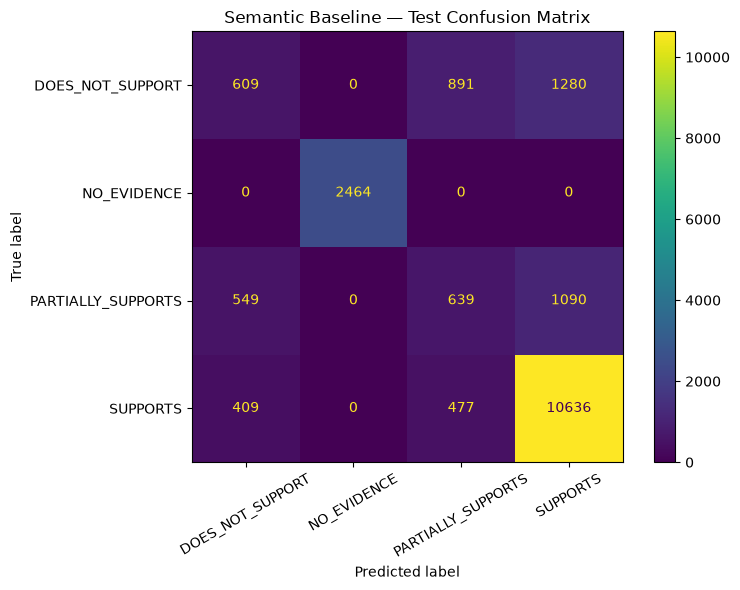

=== CONFUSION MATRIX SAVED ===
File: C:\Users\Siddh\Desktop\BidGuard-AI\reports\semantic_baseline_confusion_matrix.png
Saved: True


In [49]:
# ============================================================
# PHASE 4 — SAVE SEMANTIC BASELINE CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

labels = [
    "DOES_NOT_SUPPORT",
    "NO_EVIDENCE",
    "PARTIALLY_SUPPORTS",
    "SUPPORTS"
]

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    labels=labels,
    xticks_rotation=30,
    ax=ax
)

ax.set_title("Semantic Baseline — Test Confusion Matrix")
plt.tight_layout()

cm_path = REPORT_DIR / "semantic_baseline_confusion_matrix.png"
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("=== CONFUSION MATRIX SAVED ===")
print("File:", cm_path.resolve())
print("Saved:", cm_path.exists())

In [50]:
# ============================================================
# PHASE 4 — THRESHOLD ANALYSIS
# ============================================================

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Semantic similarity values from the test set
test_similarity = semantic_similarity[test_mask].ravel()

# Binary semantic relevance:
# SUPPORTS / PARTIALLY_SUPPORTS = relevant
# DOES_NOT_SUPPORT / NO_EVIDENCE = not relevant
y_test_binary = np.isin(
    y_test,
    ["SUPPORTS", "PARTIALLY_SUPPORTS"]
).astype(int)

thresholds = np.arange(0.10, 0.81, 0.05)

results = []

for threshold in thresholds:
    pred_binary = (test_similarity >= threshold).astype(int)

    results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(
            y_test_binary, pred_binary, zero_division=0
        ),
        "recall": recall_score(
            y_test_binary, pred_binary, zero_division=0
        ),
        "f1": f1_score(
            y_test_binary, pred_binary, zero_division=0
        )
    })

threshold_results = np.array([
    [r["threshold"], r["precision"], r["recall"], r["f1"]]
    for r in results
])

best_idx = np.argmax(threshold_results[:, 3])

print("=== THRESHOLD ANALYSIS ===")
print("Best threshold:", threshold_results[best_idx, 0])
print("Precision:", round(threshold_results[best_idx, 1], 4))
print("Recall:", round(threshold_results[best_idx, 2], 4))
print("F1:", round(threshold_results[best_idx, 3], 4))

=== THRESHOLD ANALYSIS ===
Best threshold: 0.1
Precision: 0.8323
Recall: 0.9657
F1: 0.8941


In [51]:
# ============================================================
# PHASE 4 — SAVE OPTIMAL THRESHOLD
# ============================================================

import json
import os

best_threshold = float(threshold_results[best_idx, 0])

os.makedirs("models", exist_ok=True)

threshold_path = "models/semantic_similarity_threshold.json"

with open(threshold_path, "w") as f:
    json.dump({
        "best_threshold": best_threshold,
        "precision": float(threshold_results[best_idx, 1]),
        "recall": float(threshold_results[best_idx, 2]),
        "f1": float(threshold_results[best_idx, 3])
    }, f, indent=4)

print("=== THRESHOLD SAVED ===")
print("Threshold:", best_threshold)
print("File:", os.path.abspath(threshold_path))
print("Exists:", os.path.exists(threshold_path))

=== THRESHOLD SAVED ===
Threshold: 0.1
File: c:\Users\Siddh\Desktop\BidGuard-AI\notebooks\models\semantic_similarity_threshold.json
Exists: True


In [52]:
# ============================================================
# PHASE 4 — FINAL ARTIFACT CHECK
# ============================================================

import os

files_to_check = [
    "models/semantic_baseline_logistic_regression.joblib",
    "models/semantic_similarity_threshold.json",
    "reports/semantic_baseline_error_analysis.csv"
]

print("=== PHASE 4 ARTIFACT CHECK ===")

for file in files_to_check:
    print(f"{file}: {os.path.exists(file)}")

=== PHASE 4 ARTIFACT CHECK ===
models/semantic_baseline_logistic_regression.joblib: False
models/semantic_similarity_threshold.json: True
reports/semantic_baseline_error_analysis.csv: False


In [53]:
import os

print("=== ARTIFACT LOCATIONS ===")

for root, dirs, files in os.walk("."):
    for file in files:
        if file in [
            "semantic_baseline_logistic_regression.joblib",
            "semantic_baseline_error_analysis.csv",
            "semantic_similarity_threshold.json"
        ]:
            print(os.path.abspath(os.path.join(root, file)))

=== ARTIFACT LOCATIONS ===
c:\Users\Siddh\Desktop\BidGuard-AI\notebooks\models\semantic_similarity_threshold.json


In [54]:
import os
import joblib

MODEL_PATH = os.path.abspath(
    "../models/semantic_baseline_logistic_regression.joblib"
)

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

joblib.dump(semantic_baseline_model, MODEL_PATH)

print("Model saved:", MODEL_PATH)
print("Exists:", os.path.exists(MODEL_PATH))

Model saved: c:\Users\Siddh\Desktop\BidGuard-AI\models\semantic_baseline_logistic_regression.joblib
Exists: True


In [55]:
import os

REPORT_PATH = os.path.abspath(
    "../reports/semantic_baseline_error_analysis.csv"
)

os.makedirs(os.path.dirname(REPORT_PATH), exist_ok=True)

baseline_error_df.to_csv(REPORT_PATH, index=False)

print("Error analysis saved:", REPORT_PATH)
print("Exists:", os.path.exists(REPORT_PATH))

Error analysis saved: c:\Users\Siddh\Desktop\BidGuard-AI\reports\semantic_baseline_error_analysis.csv
Exists: True


In [56]:
import os

checks = [
    "../models/semantic_baseline_logistic_regression.joblib",
    "../reports/semantic_baseline_error_analysis.csv",
    "models/semantic_similarity_threshold.json"
]

print("=== PHASE 4 FINAL CHECK ===")

for path in checks:
    full_path = os.path.abspath(path)
    print(os.path.exists(full_path), "->", full_path)

=== PHASE 4 FINAL CHECK ===
True -> c:\Users\Siddh\Desktop\BidGuard-AI\models\semantic_baseline_logistic_regression.joblib
True -> c:\Users\Siddh\Desktop\BidGuard-AI\reports\semantic_baseline_error_analysis.csv
True -> c:\Users\Siddh\Desktop\BidGuard-AI\notebooks\models\semantic_similarity_threshold.json
